In [1]:
import os

dataset_path = "/kaggle/input/datasets/arnaudeq/cats-vs-dogs-1000/dogs_cats_sample_1000"

print(os.listdir(dataset_path))

['dogs_cats_sample_1000', 'valid', 'train']


In [2]:
import os

train_path = "/kaggle/input/datasets/arnaudeq/cats-vs-dogs-1000/dogs_cats_sample_1000/train"
valid_path = "/kaggle/input/datasets/arnaudeq/cats-vs-dogs-1000/dogs_cats_sample_1000/valid"

print("Train folders:", os.listdir(train_path))
print("Validation folders:", os.listdir(valid_path))

Train folders: ['dogs', 'cats']
Validation folders: ['dogs', 'cats']


In [3]:
import tensorflow as tf

IMG_SIZE = (224,224)

BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(

    "/kaggle/input/datasets/arnaudeq/cats-vs-dogs-1000/dogs_cats_sample_1000/train",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)

validation_dataset = tf.keras.utils.image_dataset_from_directory(

    "/kaggle/input/datasets/arnaudeq/cats-vs-dogs-1000/dogs_cats_sample_1000/valid",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)

Found 2000 files belonging to 2 classes.


I0000 00:00:1783138576.123008      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783138576.125953      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 2000 files belonging to 2 classes.


In [4]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

In [5]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
base_model.trainable = False

print(base_model.trainable)

False


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dense(1, activation='sigmoid')

])

In [8]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [9]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=10

)

Epoch 1/10


2026-07-04 04:16:35.646736: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 04:16:35.783376: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1783138597.534453      77 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9584 - loss: 0.1236

2026-07-04 04:16:48.242384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 04:16:48.380891: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 353ms/step - accuracy: 0.9760 - loss: 0.0704 - val_accuracy: 0.9815 - val_loss: 0.0676
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9950 - loss: 0.0137 - val_accuracy: 0.9820 - val_loss: 0.0815
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9975 - loss: 0.0073 - val_accuracy: 0.9830 - val_loss: 0.0753
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9985 - loss: 0.0051 - val_accuracy: 0.9850 - val_loss: 0.0732
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9840 - val_loss: 0.0810
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9865 - val_loss: 0.0838
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 1.0000 - loss: 3.9282e-04 - val_accuracy: 0.9865 - val_loss: 0.0828
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 1.0000 - loss: 2.7856e-04 - val_accuracy: 0.9865 - va

In [10]:
import os

print(len(os.listdir("/kaggle/input/datasets/arnaudeq/cats-vs-dogs-1000/dogs_cats_sample_1000/train/cats")))
print(len(os.listdir("/kaggle/input/datasets/arnaudeq/cats-vs-dogs-1000/dogs_cats_sample_1000/train/dogs")))
print(len(os.listdir("/kaggle/input/datasets/arnaudeq/cats-vs-dogs-1000/dogs_cats_sample_1000/valid/cats")))
print(len(os.listdir("/kaggle/input/datasets/arnaudeq/cats-vs-dogs-1000/dogs_cats_sample_1000/valid/dogs")))

1000
1000
1002
998


In [11]:
base_model.trainable = True

In [12]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-5),

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [13]:
history_fine = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=5

)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 612ms/step - accuracy: 0.8960 - loss: 0.4093 - val_accuracy: 0.9805 - val_loss: 0.1198
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.9700 - loss: 0.0661 - val_accuracy: 0.9795 - val_loss: 0.1300
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.9795 - loss: 0.0500 - val_accuracy: 0.9810 - val_loss: 0.1226
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.9915 - loss: 0.0278 - val_accuracy: 0.9830 - val_loss: 0.1136
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.9855 - loss: 0.0374 - val_accuracy: 0.9815 - val_loss: 0.1200


In [14]:
model.save("cats_vs_dogs.keras")

In [15]:

# TESTING Cat
from tensorflow.keras.models import load_model

model = load_model("cats_vs_dogs.keras")

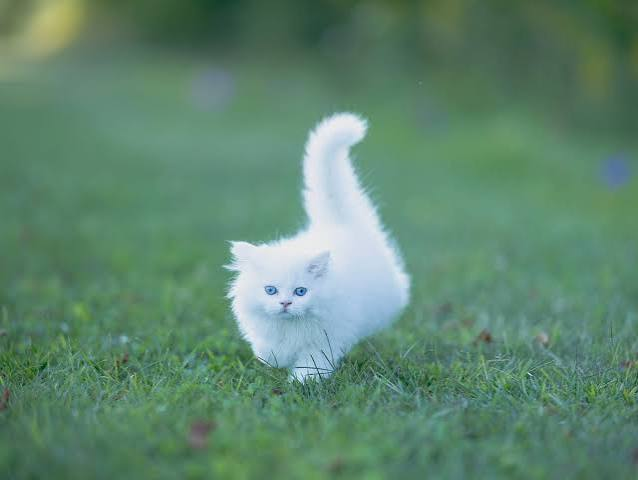

In [16]:
from IPython.display import Image, display

image_path = ("/kaggle/input/datasets/mudassarshabir/catcat/cat.jpg")   # Change this path

display(Image(filename=image_path))

In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load image
img = image.load_img(image_path, target_size=(224, 224))

# Convert image to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# MobileNetV2 preprocessing
img_array = preprocess_input(img_array)

In [18]:
prediction = model.predict(img_array)

print(prediction)

2026-07-04 04:19:39.336369: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 04:19:39.493091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 04:19:39.626460: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
[[0.06308071]]


In [19]:
if prediction[0][0] > 0.5:
    print("🐶 Dog")
else:
    print("🐱 Cat")

🐱 Cat


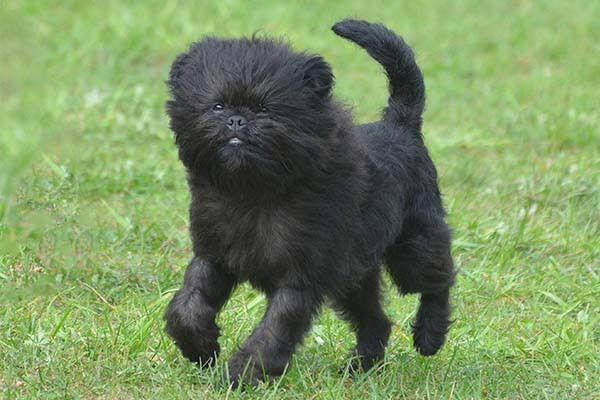

In [20]:
# TESTING dog

from IPython.display import Image, display

image_path = ("/kaggle/input/datasets/mudassarshabir/dogdog/dog.jpg")   # Change this path

display(Image(filename=image_path))

In [21]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load image
img = image.load_img(image_path, target_size=(224, 224))

# Convert image to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# MobileNetV2 preprocessing
img_array = preprocess_input(img_array)

In [22]:
prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[[0.9999944]]


In [23]:
if prediction[0][0] > 0.5:
    print("🐶 Dog")
else:
    print("🐱 Cat")

🐶 Dog
